<a href="https://colab.research.google.com/github/richayanamandra/GenAI-Experiments/blob/main/genAI_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [1]:
BATCH_SIZE = 64
NUM_EPOCHS = 20
LR         = 2e-4

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch

class PairedCIFAR10(Dataset):
    def __init__(self, train=True):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))  # → [-1,1]
        ])
        self.data = torchvision.datasets.CIFAR10(
            root='./data', train=train, download=True, transform=transform
        )
        self.gray_weights = torch.tensor([0.299, 0.587, 0.114]).view(3,1,1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        color, label = self.data[idx]
        gray = (color * self.gray_weights).sum(0, keepdim=True).repeat(3,1,1)
        return gray, color   # input=grayscale, target=color

train_loader = DataLoader(PairedCIFAR10(train=True),  batch_size=64, shuffle=True)
test_loader  = DataLoader(PairedCIFAR10(train=False), batch_size=64, shuffle=False)
print("Data loaded and normalized to [-1, 1]")

100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


Train samples: 50000
Test  samples: 10000


In [2]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch

class PairedCIFAR10(Dataset):
    def __init__(self, train=True):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))  # → [-1,1]
        ])
        self.data = torchvision.datasets.CIFAR10(
            root='./data', train=train, download=True, transform=transform
        )
        self.gray_weights = torch.tensor([0.299, 0.587, 0.114]).view(3,1,1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        color, label = self.data[idx]
        gray = (color * self.gray_weights).sum(0, keepdim=True).repeat(3,1,1)
        return gray, color   # input=grayscale, target=color

train_loader = DataLoader(PairedCIFAR10(train=True),  batch_size=64, shuffle=True)
test_loader  = DataLoader(PairedCIFAR10(train=False), batch_size=64, shuffle=False)
print("Data loaded and normalized to [-1, 1]")

100%|██████████| 170M/170M [00:05<00:00, 29.5MB/s]


Data loaded and normalized to [-1, 1]


In [5]:
import torch.nn as nn

class EncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: compress image
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64,  3, padding=1),  nn.ReLU(),  # 32x32
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),  # 32x32
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(),  # 16x16
        )

        # Decoder: reconstruct image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.ReLU(),  # 32x32
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 3,  3, padding=1), nn.Tanh()   # output [-1,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = EncoderDecoder().to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

EncoderDecoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Tanh()
  )
)
Parameters: 970,755


In [6]:
import torch.optim as optim

criterion_mse = nn.MSELoss()
criterion_l1  = nn.L1Loss()
optimizer     = optim.Adam(model.parameters(), lr=2e-4)

mse_history, l1_history = [], []

for epoch in range(1, 21):
    model.train()
    total_mse, total_l1 = 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        mse = criterion_mse(outputs, targets)
        l1  = criterion_l1(outputs, targets)
        loss = mse + l1

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_mse += mse.item()
        total_l1  += l1.item()

    avg_mse = total_mse / len(train_loader)
    avg_l1  = total_l1  / len(train_loader)
    mse_history.append(avg_mse)
    l1_history.append(avg_l1)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch}/20] MSE: {avg_mse:.4f} | L1: {avg_l1:.4f}')

Epoch [1/20] MSE: 0.0322 | L1: 0.1180
Epoch [5/20] MSE: 0.0222 | L1: 0.0929
Epoch [10/20] MSE: 0.0214 | L1: 0.0911
Epoch [15/20] MSE: 0.0210 | L1: 0.0900
Epoch [20/20] MSE: 0.0207 | L1: 0.0893


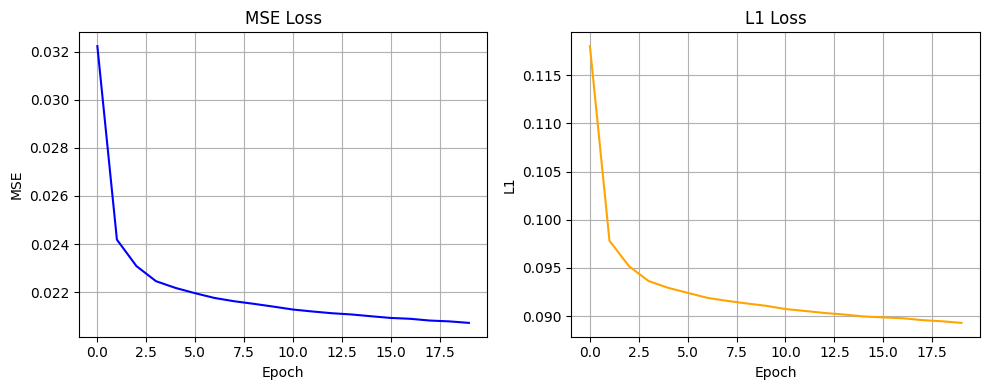

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(mse_history, color='blue')
plt.title('MSE Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(l1_history, color='orange')
plt.title('L1 Loss'); plt.xlabel('Epoch'); plt.ylabel('L1')
plt.grid(True)

plt.tight_layout()
plt.show()

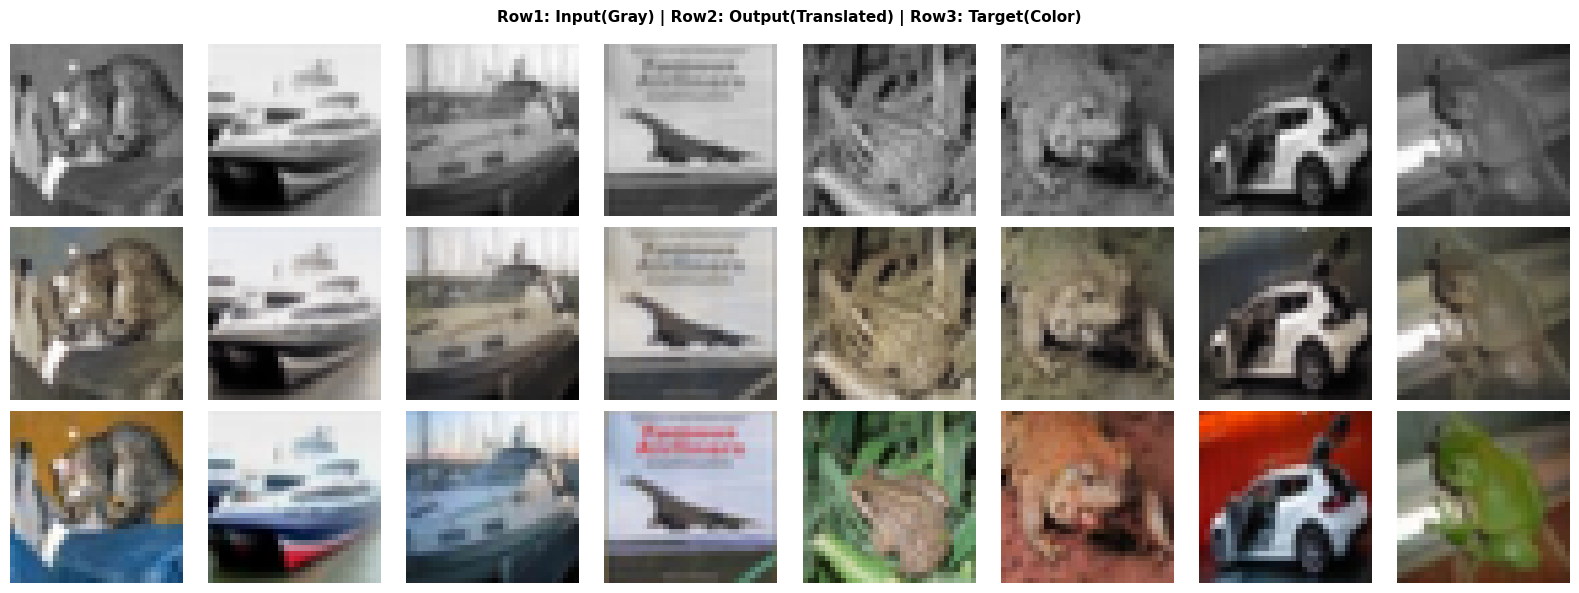

In [8]:
import numpy as np

model.eval()
inputs, targets = next(iter(test_loader))

with torch.no_grad():
    outputs = model(inputs.to(device)).cpu()

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0,1)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Row1: Input(Gray) | Row2: Output(Translated) | Row3: Target(Color)',
             fontsize=11, fontweight='bold')

for i in range(8):
    for row, data in enumerate([inputs, outputs, targets]):
        axes[row, i].imshow(np.clip(denorm(data[i]).permute(1,2,0).numpy(), 0, 1))
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()